In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import pandas as pd
import pickle
import copy

from imports import *
from config import dir_config, ephys_config
from src.utils import dpca_utils, dpca_plot_utils, ephys_utils

In [4]:
compiled_dir  = Path(dir_config.data.compiled)
processed_dir = Path(dir_config.data.processed)


COH_LABELS = ["0%", "6%", "20%", "50%"]


# Laod Data

In [5]:
session_to_exclude = ["210210_GP_JP", "241209_GP_TZ"]

session_metadata = pd.read_csv(Path(processed_dir, "sessions_metadata.csv"))
session_metadata = session_metadata[~session_metadata.session_id.isin(session_to_exclude)].reset_index(drop=True)

neuron_metadata = pd.read_csv(Path(processed_dir, "neuron_metadata.csv"))
neuron_metadata = neuron_metadata[~neuron_metadata.session_id.isin(session_to_exclude)].reset_index(drop=True)

trial_info = {}
eq_trial_info = {}
uneq_trial_info = {}
for session_id in session_metadata.session_id:
    session_trial_info = pd.read_csv(compiled_dir / session_id / f"{session_id}_trial_cleaned.csv")
    session_trial_info = session_trial_info[(session_trial_info.task_type == 1) & (session_trial_info.outcome.isin([0, 1]))]
    trial_info[session_id] = session_trial_info
    eq_trial_info = trial_info[session_id][trial_info[session_id].prob_toRF == 50]
    uneq_trial_info = trial_info[session_id][trial_info[session_id].prob_toRF == 50]


with open(Path(processed_dir, "ephys_neuron_wise.pkl"), "rb") as f:
    ephys = pickle.load(f)

In [6]:
def get_trial_num(trial_data, coherence=None, target=None, choice=None, outcome=None):
    trial_mask = np.ones(len(trial_data), dtype=bool)
    if coherence is not None:
        trial_mask = trial_mask & (trial_data.coherence == coherence)
    if target is not None:
        trial_mask = trial_mask & (trial_data.target == target)
    if choice is not None:
        trial_mask = trial_mask & (trial_data.choice == choice)
    if outcome is not None:
        trial_mask = trial_mask & (trial_data.outcome == outcome)
    selected_trials = trial_data[trial_mask]
    return np.array(selected_trials.trial_number.values.reshape(-1, 1))


def prepare_dpca_data(sessions, condition_dict, session_neuron_ids, trial_info, outcome=None, verbose=True):

    missing_session = []

    alignment_settings = ephys_config["alignment_settings_GP"]
    n_neurons    = len(session_neuron_ids)
    n_targets     = len(condition_dict["target"])
    n_coherences = len(condition_dict["coherences"])
    n_choices    = len(condition_dict["choices"])


    dPCA_averaged_data = {
        event: np.full(
            [n_neurons, n_targets, n_coherences, n_choices,
             alignment_settings[event]["end_time_ms"] - alignment_settings[event]["start_time_ms"] + 1],
            np.nan,
        )
        for event in alignment_settings
    }

    dPCA_trial_wise_data = {
        event: np.full(
            [300, n_neurons, n_targets, n_coherences, n_choices,
             alignment_settings[event]["end_time_ms"] - alignment_settings[event]["start_time_ms"] + 1],
            np.nan, dtype=np.float32,
        )
        for event in alignment_settings
    }

    for alignment in alignment_settings:
        for session_id in sessions:
            neuron_ids = neuron_metadata.neuron_id[neuron_metadata.session_id == session_id].values
            neuron_ids = neuron_ids[np.isin(neuron_ids, session_neuron_ids)]
            for target_idx, target in enumerate(condition_dict["target"]):
                for coherence_idx, coherence in enumerate(condition_dict["coherences"]):
                    for choice_idx, choice in enumerate(condition_dict["choices"]):
                        trials = get_trial_num(trial_info[session_id], coherence=coherence, target=target, choice=choice, outcome=outcome)

                        # if len(trials) == 0:
                        if len(trials) < 4:
                            if verbose:
                                print(f"No trials in: session_id:{session_id}, target:{target}, coherence:{coherence}, choice:{choice}")
                            missing_session.append((session_id, target, coherence, choice))
                            continue

                        for neuron_id in neuron_ids:
                            trial_wise_data = ephys_utils.get_neural_data_from_trial_num(
                                ephys[alignment][neuron_id], trials, type="convolved_spike_trains"
                            )
                            averaged_data = np.nanmean(trial_wise_data, axis=0)
                            n_idx = np.where(session_neuron_ids == neuron_id)[0]

                            if alignment == "cue":
                                non_nan_tp = np.where(
                                    np.sum(np.isnan(trial_wise_data), axis=0) / len(trials) <= 0.7
                                )[0]
                                averaged_data = averaged_data[: non_nan_tp[-1] + 1]
                                dPCA_averaged_data[alignment][
                                    n_idx, target_idx, coherence_idx, choice_idx, : len(averaged_data)
                                ] = averaged_data
                            elif alignment == "response":
                                non_nan_tp = np.where(
                                    np.sum(np.isnan(trial_wise_data), axis=0) / len(trials) <= 0.7
                                )[0]
                                averaged_data = averaged_data[non_nan_tp[0] :]
                                dPCA_averaged_data[alignment][
                                    n_idx, target_idx, coherence_idx, choice_idx, -len(averaged_data) :
                                ] = averaged_data
                            else:
                                dPCA_averaged_data[alignment][
                                    n_idx, target_idx, coherence_idx, choice_idx, :
                                ] = averaged_data

                            dPCA_trial_wise_data[alignment][
                                : trial_wise_data.shape[0],
                                n_idx,
                                target_idx,
                                coherence_idx,
                                choice_idx,
                                :,
                            ] = np.expand_dims(trial_wise_data, axis=1)

    return dPCA_averaged_data, dPCA_trial_wise_data, missing_session

In [7]:
toRF_sessions  = session_metadata.session_id[session_metadata.prior_direction == "toRF"]
awayRF_sessions = session_metadata.session_id[session_metadata.prior_direction == "awayRF"]

alignments = list(ephys_config["alignment_settings_GP"].keys())  # ['baseline','visual','cue','response']
marginalization_keys = ['g', 's', 'c', 't']

condition_dict_blocks = {
    "target": [0, 1],
    "coherences":   [0, 6, 20],
    "choices":      [0, 1],
}

neuron_ids = dpca_utils.get_neuron_ids(neuron_metadata, toRF_sessions)

avg, tw, missing_session = prepare_dpca_data(toRF_sessions, condition_dict_blocks, neuron_ids, trial_info)
fit_avg, fit_tw, full_avg, full_tw = dpca_utils.clean_dpca_data(avg, tw, alignments)

dpca_results = dpca_utils.fit_dpca_all_alignments(fit_avg, fit_tw, alignments, marginalization_keys=marginalization_keys)
projections   = dpca_utils.cross_period_projection(dpca_results, fit_avg, alignments)
time_axes     = dpca_utils.build_time_axes(fit_avg, ephys_config)

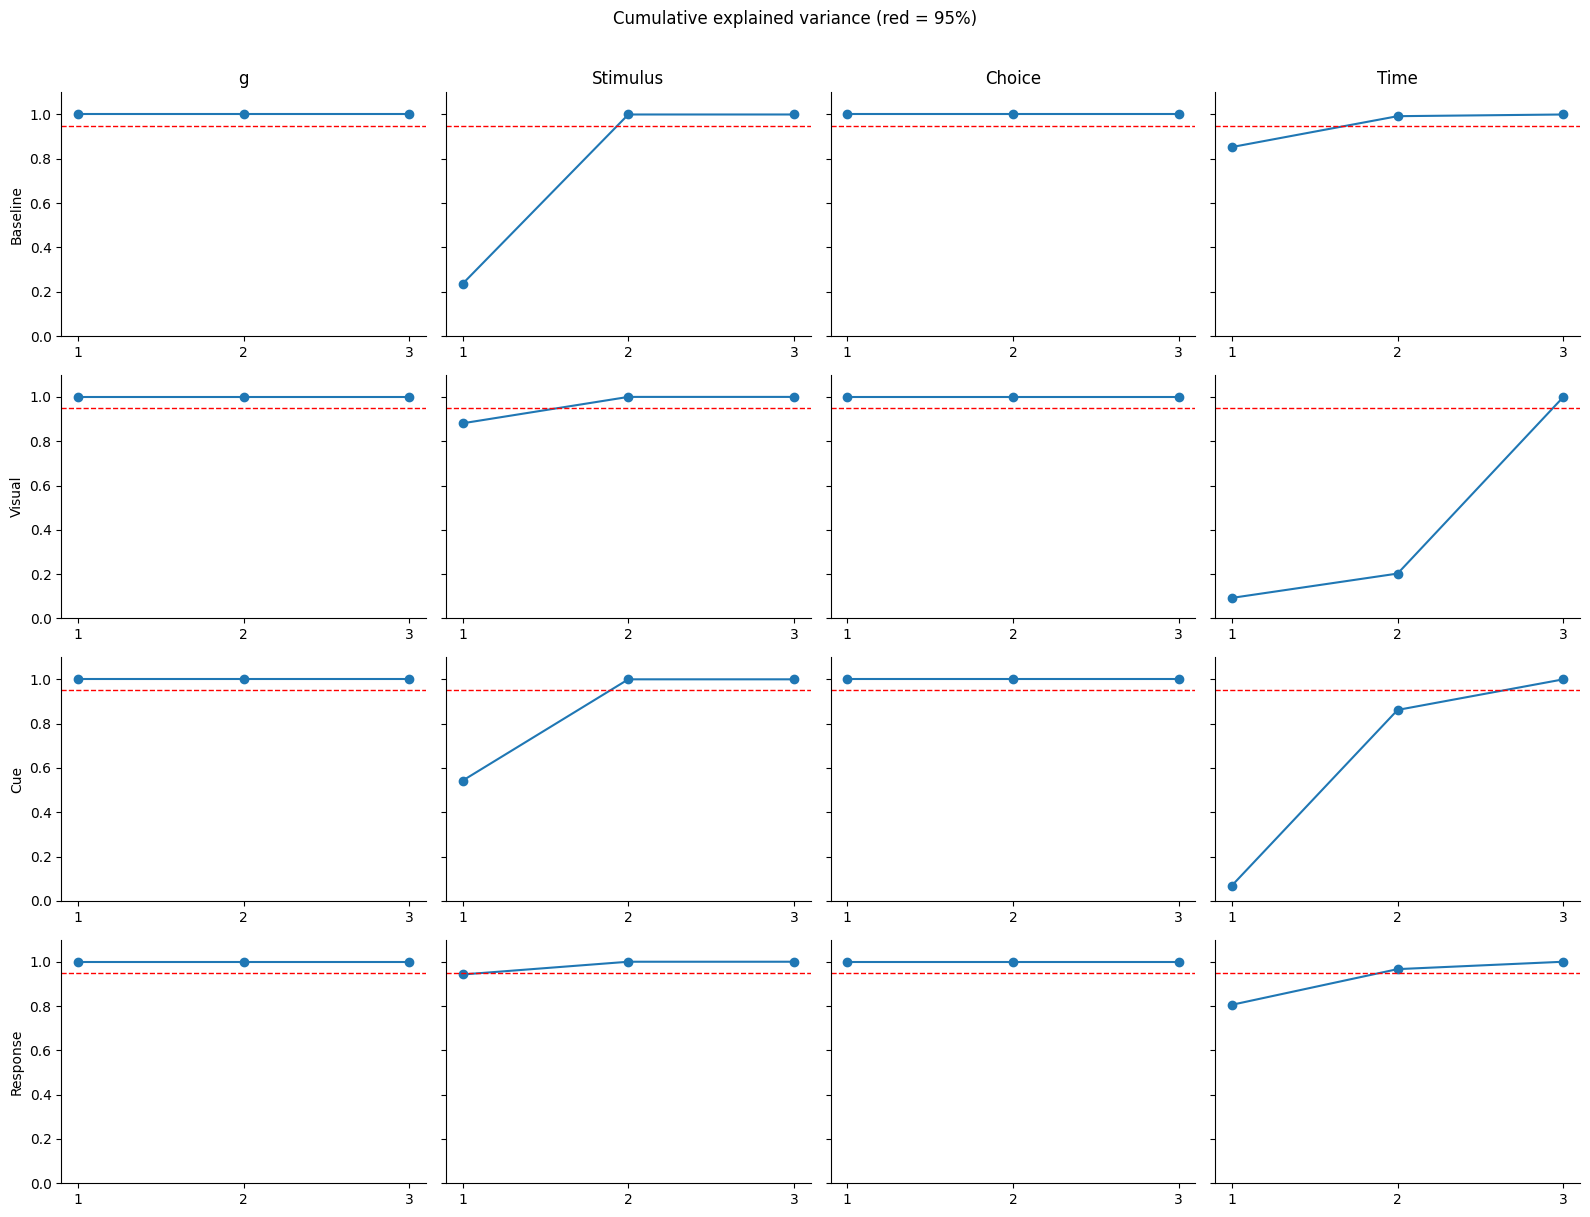

In [8]:
margs_to_plot = ['g', 's', 'c', 't']
n_components  = 3
fig = dpca_plot_utils.plot_variance_explained(dpca_results, alignments, margs_to_plot, n_components=n_components)
plt.show()


In [9]:
# Significance masks — binary low (0%,6%) vs high (20%,50%) coherence classifier
# smooth_sigma=10 applies Gaussian smoothing to true scores before thresholding against null.


projection = {}
significance_masks = {}
true_scores = {}
shuffle_scores = {}
time_axes = {}
for trial_type in ["correct", "error"]:
    outcome = 1 if trial_type == "correct" else 0
    avg, tw, missing_session = prepare_dpca_data(toRF_sessions, condition_dict_blocks, neuron_ids, trial_info, outcome, verbose=False)
    fit_avg, fit_tw, full_avg, full_tw = dpca_utils.clean_dpca_data(avg, tw, alignments)

    time_axes[trial_type]     = dpca_utils.build_time_axes(fit_avg, ephys_config)

    projection[trial_type] = dpca_utils.cross_period_projection(dpca_results, fit_avg, alignments)

    significance_masks[trial_type] = {}
    true_scores[trial_type] = {}
    shuffle_scores[trial_type] = {}
    for alignment in alignments:
        dpca_model = dpca_results[alignment]["model"]
        print(f"Computing significance masks for {alignment} alignment...")


        significance_masks[trial_type][alignment], true_scores[trial_type][alignment], shuffle_scores[trial_type][alignment] = \
            dpca_utils.dpca_significance_analysis(
                copy.deepcopy(dpca_model), fit_avg[alignment], fit_tw[alignment],
                n_shuffles=100, n_splits=50, n_consecutive=1,
                keys=['g', 's', 'c'],
                key_groups={'s': [[0, 1], [2]]},
                smooth_sigma=10,
                refit=False,
            )

# significance_masks[alignment][marg_key] → bool array (n_components, n_time)


Computing significance masks for baseline alignment...
Computing true score (50 splits)...


True score done.
Running 100 shuffles (32 parallel jobs)...


[Parallel(n_jobs=32)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done   8 tasks      | elapsed:   18.9s
[Parallel(n_jobs=32)]: Done  21 tasks      | elapsed:   21.0s
[Parallel(n_jobs=32)]: Done  34 tasks      | elapsed:   34.0s
[Parallel(n_jobs=32)]: Done  48 out of 100 | elapsed:   36.6s remaining:   39.6s
[Parallel(n_jobs=32)]: Done  59 out of 100 | elapsed:   40.5s remaining:   28.1s
[Parallel(n_jobs=32)]: Done  70 out of 100 | elapsed:   50.5s remaining:   21.7s
[Parallel(n_jobs=32)]: Done  81 out of 100 | elapsed:   52.4s remaining:   12.3s
[Parallel(n_jobs=32)]: Done  92 out of 100 | elapsed:   55.6s remaining:    4.8s
[Parallel(n_jobs=32)]: Done 100 out of 100 | elapsed:   56.8s finished


Shuffles done. Computing masks...
Computing significance masks for visual alignment...
Computing true score (50 splits)...
True score done.
Running 100 shuffles (32 parallel jobs)...


[Parallel(n_jobs=32)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done   8 tasks      | elapsed:   16.7s
[Parallel(n_jobs=32)]: Done  21 tasks      | elapsed:   17.7s
[Parallel(n_jobs=32)]: Done  34 tasks      | elapsed:   31.7s
[Parallel(n_jobs=32)]: Done  48 out of 100 | elapsed:   33.3s remaining:   36.1s
[Parallel(n_jobs=32)]: Done  59 out of 100 | elapsed:   36.4s remaining:   25.3s
[Parallel(n_jobs=32)]: Done  70 out of 100 | elapsed:   48.4s remaining:   20.7s
[Parallel(n_jobs=32)]: Done  81 out of 100 | elapsed:   49.0s remaining:   11.5s
[Parallel(n_jobs=32)]: Done  92 out of 100 | elapsed:   50.9s remaining:    4.4s
[Parallel(n_jobs=32)]: Done 100 out of 100 | elapsed:   53.9s finished


...

Shuffles done. Computing masks...
Computing significance masks for cue alignment...
Computing true score (50 splits)...
True score done.
Running 100 shuffles (32 parallel jobs)...


[Parallel(n_jobs=32)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done   8 tasks      | elapsed:   20.6s
[Parallel(n_jobs=32)]: Done  21 tasks      | elapsed:   21.7s
[Parallel(n_jobs=32)]: Done  34 tasks      | elapsed:   39.1s
[Parallel(n_jobs=32)]: Done  48 out of 100 | elapsed:   42.0s remaining:   45.5s
[Parallel(n_jobs=32)]: Done  59 out of 100 | elapsed:   44.2s remaining:   30.7s
[Parallel(n_jobs=32)]: Done  70 out of 100 | elapsed:  1.0min remaining:   25.9s
[Parallel(n_jobs=32)]: Done  81 out of 100 | elapsed:  1.0min remaining:   14.5s
[Parallel(n_jobs=32)]: Done  92 out of 100 | elapsed:  1.1min remaining:    5.5s
[Parallel(n_jobs=32)]: Done 100 out of 100 | elapsed:  1.1min finished


Shuffles done. Computing masks...
Computing significance masks for response alignment...
Computing true score (50 splits)...
True score done.
Running 100 shuffles (32 parallel jobs)...


[Parallel(n_jobs=32)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done   8 tasks      | elapsed:   15.4s
[Parallel(n_jobs=32)]: Done  21 tasks      | elapsed:   16.9s
[Parallel(n_jobs=32)]: Done  34 tasks      | elapsed:   29.2s
[Parallel(n_jobs=32)]: Done  48 out of 100 | elapsed:   32.2s remaining:   34.9s
[Parallel(n_jobs=32)]: Done  59 out of 100 | elapsed:   34.0s remaining:   23.7s
[Parallel(n_jobs=32)]: Done  70 out of 100 | elapsed:   45.6s remaining:   19.5s
[Parallel(n_jobs=32)]: Done  81 out of 100 | elapsed:   47.7s remaining:   11.2s
[Parallel(n_jobs=32)]: Done  92 out of 100 | elapsed:   48.5s remaining:    4.2s
[Parallel(n_jobs=32)]: Done 100 out of 100 | elapsed:   51.2s finished


Shuffles done. Computing masks...


In [10]:
# # Significance masks — binary low (0%,6%) vs high (20%,50%) coherence classifier
# # smooth_sigma=10 applies Gaussian smoothing to true scores before thresholding against null.

# significance_masks = {}
# for alignment in alignments:
#     dpca_model = dpca_results[alignment]["model"]
#     print(f"Computing significance masks for {alignment} alignment...")
#     significance_masks[alignment], _, _ = \
#         dpca_utils.dpca_significance_analysis(
#             copy.deepcopy(dpca_model), fit_avg[alignment], fit_tw[alignment],
#             n_shuffles=100, n_splits=50, n_consecutive=1,
#             keys=['g', 's', 'c'],
#             key_groups={'s': [[0, 1], [2]]},
#             smooth_sigma=10,
#         )

# # significance_masks[alignment][marg_key] → bool array (n_components, n_time)


In [11]:
# Significant bin counts per alignment / marginalization (PC1)
for trial_type in ["correct", "error"]:
    print(f"\n{trial_type.upper()} TRIALS:")

    for alignment in alignments:
        for key in ['g', 's', 'c']:
            n_sig = significance_masks[trial_type][alignment][key][0].sum()
            print(f"  {alignment}/{key}: {n_sig} significant bins (PC1)")



CORRECT TRIALS:
  baseline/g: 247 significant bins (PC1)
  baseline/s: 198 significant bins (PC1)
  baseline/c: 251 significant bins (PC1)
  visual/g: 234 significant bins (PC1)
  visual/s: 190 significant bins (PC1)
  visual/c: 251 significant bins (PC1)
  cue/g: 273 significant bins (PC1)
  cue/s: 40 significant bins (PC1)
  cue/c: 387 significant bins (PC1)
  response/g: 108 significant bins (PC1)
  response/s: 338 significant bins (PC1)
  response/c: 338 significant bins (PC1)

ERROR TRIALS:
  baseline/g: 69 significant bins (PC1)
  baseline/s: 36 significant bins (PC1)
  baseline/c: 243 significant bins (PC1)
  visual/g: 52 significant bins (PC1)
  visual/s: 82 significant bins (PC1)
  visual/c: 251 significant bins (PC1)
  cue/g: 103 significant bins (PC1)
  cue/s: 0 significant bins (PC1)
  cue/c: 334 significant bins (PC1)
  response/g: 169 significant bins (PC1)
  response/s: 248 significant bins (PC1)
  response/c: 285 significant bins (PC1)


In [12]:
LEFT_COLORS   = ["#96D6EC", "#6FC3EB", "#5289C6", "#4469B1"]
RIGHT_COLORS = ["#F2A448", "#EF8D41", "#EC6A50", "#AC3626"]

MARG_LABELS  = {"g": "Target", "s": "Stimulus", "c": "Choice", "t": "Time"}
ALIGN_LABELS = {"baseline": "Baseline", "visual": "Visual",
                "cue": "Cue", "response": "Response"}

def plot_dpca_traces(ax, time, data, n_states=2, n_coh=4,
                     biased_colors=None, unbiased_colors=None):
    """Plot all (state × coh × choice) traces for one PC onto ax.

    data : (n_states, n_coh, n_choices, n_time) as returned by dpca_transform.
    """
    if biased_colors is None:
        biased_colors = LEFT_COLORS[:n_coh]
    if unbiased_colors is None:
        unbiased_colors = RIGHT_COLORS[:n_coh]
    ls_map = ["-", "--"]
    for b in range(n_states):
        colors = biased_colors if b == 0 else unbiased_colors
        for s in range(n_coh):
            for c in range(2):
                ax.plot(time, data[b, s, c, :].reshape(-1),
                        color=colors[s], linestyle=ls_map[c], linewidth=1.5)
    ax.axvline(0, color="k", linestyle="--", linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def bar_significance(ax, time, mask):
    """Draw a thin significance bar at the bottom of ax at significant timepoints."""
    ax.fill_between(
        time, 0, 0.05,
        where=mask,
        transform=ax.get_xaxis_transform(),
        color="black", alpha=1, zorder=5,
    )

def plot_self_projection(projections, time_axes, alignments, margs_to_plot,
                         significance_masks=None, PC=0,
                         n_states=2, n_coh=4,
                         biased_colors=None, unbiased_colors=None,
                         coh_labels=None, title=None):
    """Self-projection figure: margs_to_plot × alignments grid, PC traces."""
    if biased_colors is None:
        biased_colors = LEFT_COLORS[:n_coh]
    if unbiased_colors is None:
        unbiased_colors = RIGHT_COLORS[:n_coh]
    if coh_labels is None:
        coh_labels = [f"coh{i}" for i in range(n_coh)]

    n_rows, n_cols = len(margs_to_plot), len(alignments)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))

    for col, alignment in enumerate(alignments):
        Z    = projections[alignment][alignment]
        time = time_axes[alignment]
        for row, marg in enumerate(margs_to_plot):
            if n_rows > 1 and n_cols > 1:
                ax = axes[row, col]
            elif n_rows == 1:
                ax = axes[col]
            else:
                ax = axes[row]
            plot_dpca_traces(ax, time, Z[marg][PC], n_states, n_coh,
                             biased_colors, unbiased_colors)
            if significance_masks is not None and marg in significance_masks.get(alignment, {}):
                bar_significance(ax, time, significance_masks[alignment][marg][PC])
            if row == 0:
                ax.set_title(ALIGN_LABELS.get(alignment, alignment), fontsize=13)
            if col == 0:
                ax.set_ylabel(f"{MARG_LABELS.get(marg, marg)} PC{PC + 1}", fontsize=12)

    handles = (
        [plt.Line2D([], [], color=biased_colors[i],   label=f"{coh_labels[i]} awayRF target")   for i in range(n_coh)] +
        [plt.Line2D([], [], color=unbiased_colors[i], label=f"{coh_labels[i]} toRF target") for i in range(n_coh)] +
        [plt.Line2D([], [], color="k", linestyle="-",  label="awayRF choice"),
         plt.Line2D([], [], color="k", linestyle="--", label="toRF choice"),
         plt.Rectangle((0, 0), 1, 0.05, fc="black", label="significant")]
    )
    fig.legend(handles=handles, bbox_to_anchor=(1.01, 0.9), loc="upper left", fontsize=10)
    if title:
        fig.suptitle(title, y=1.01)
    plt.tight_layout()
    return fig



CORRECT TRIALS:


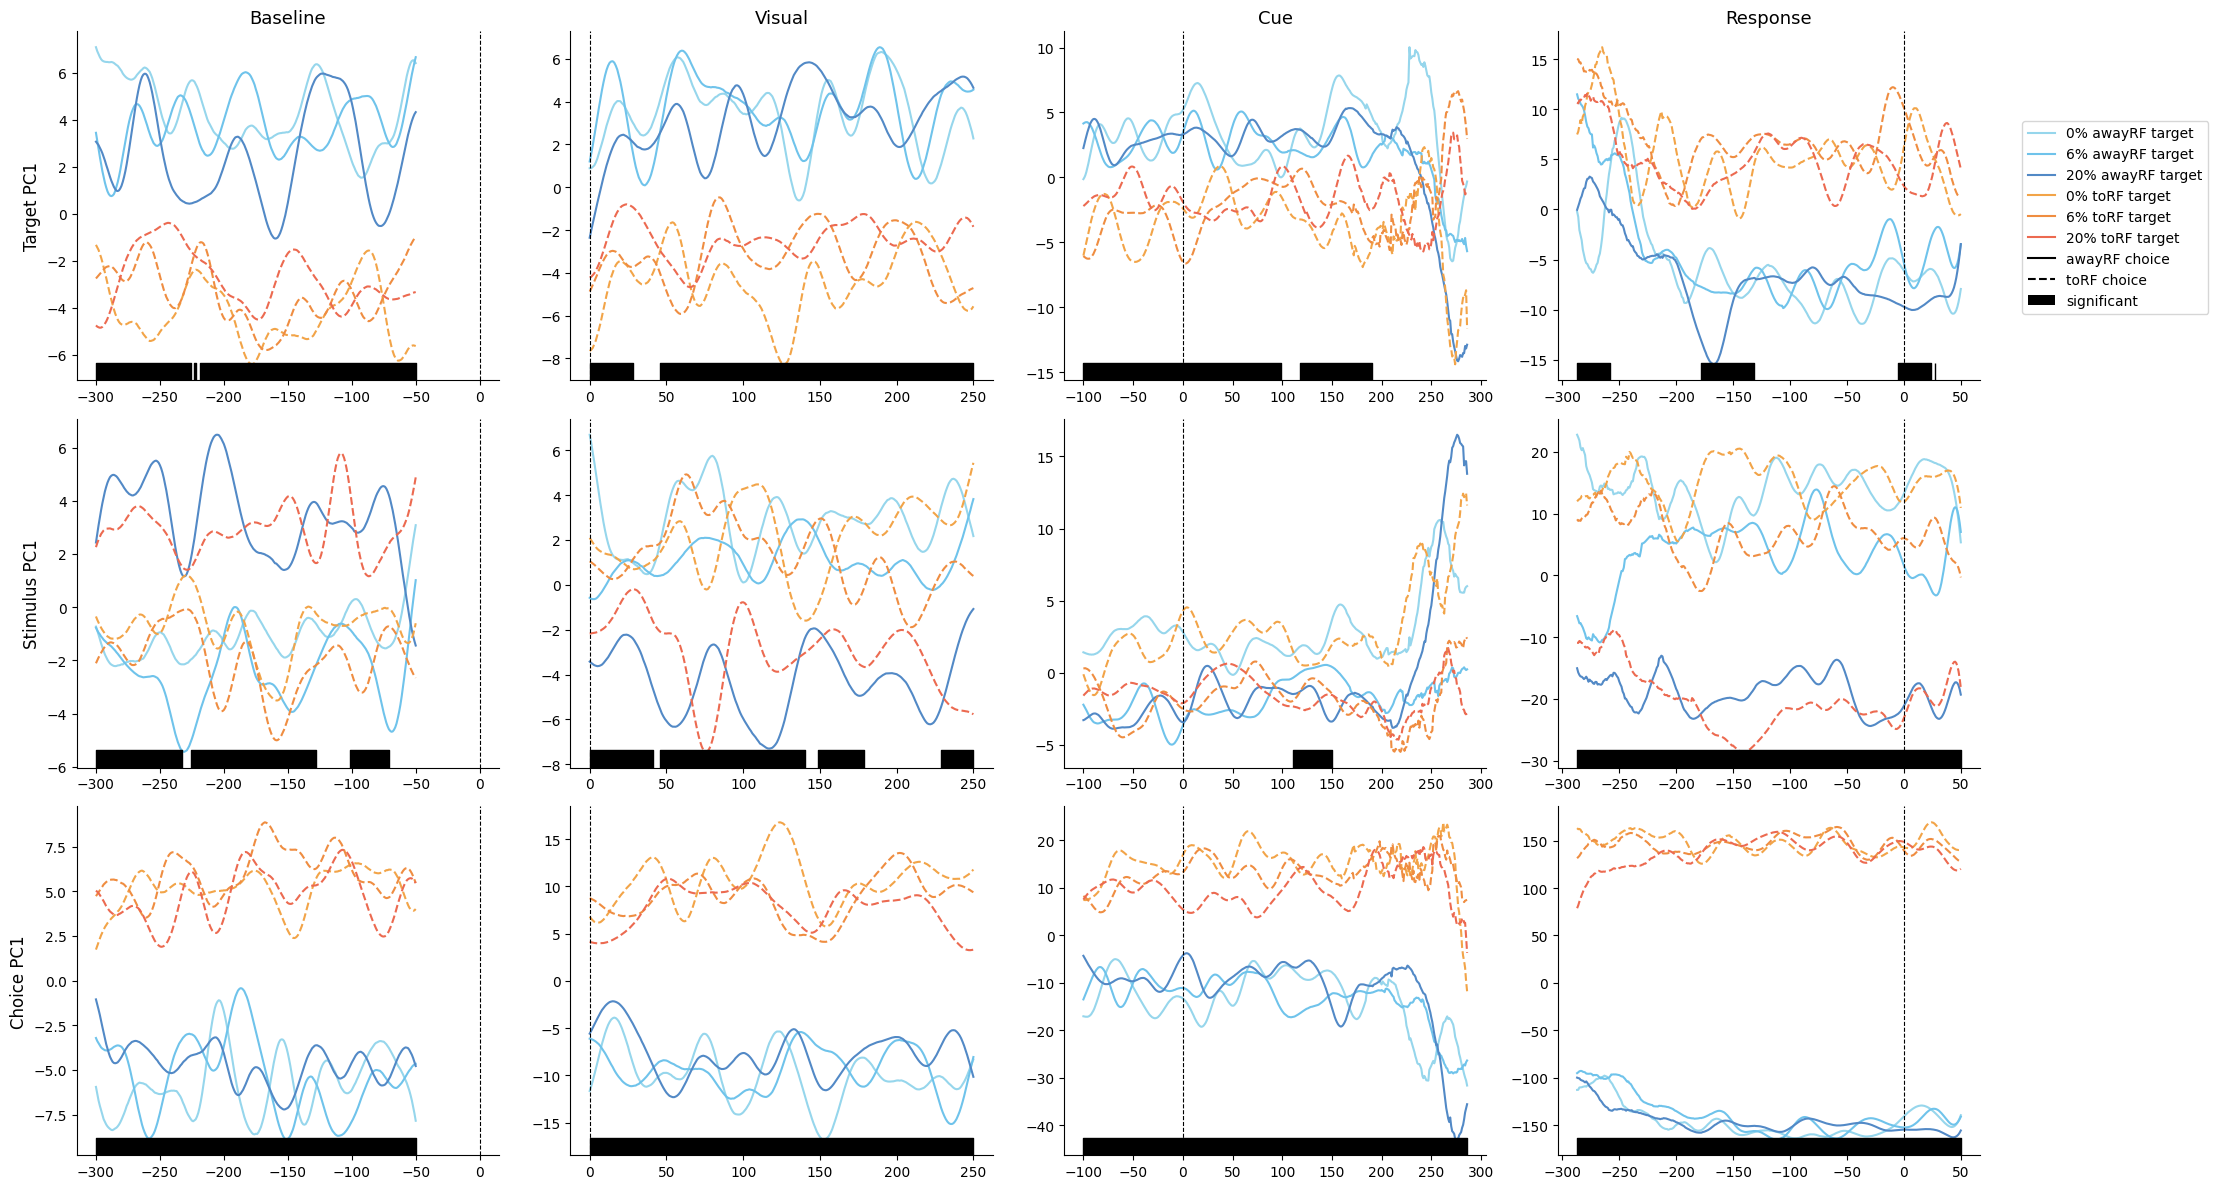


ERROR TRIALS:


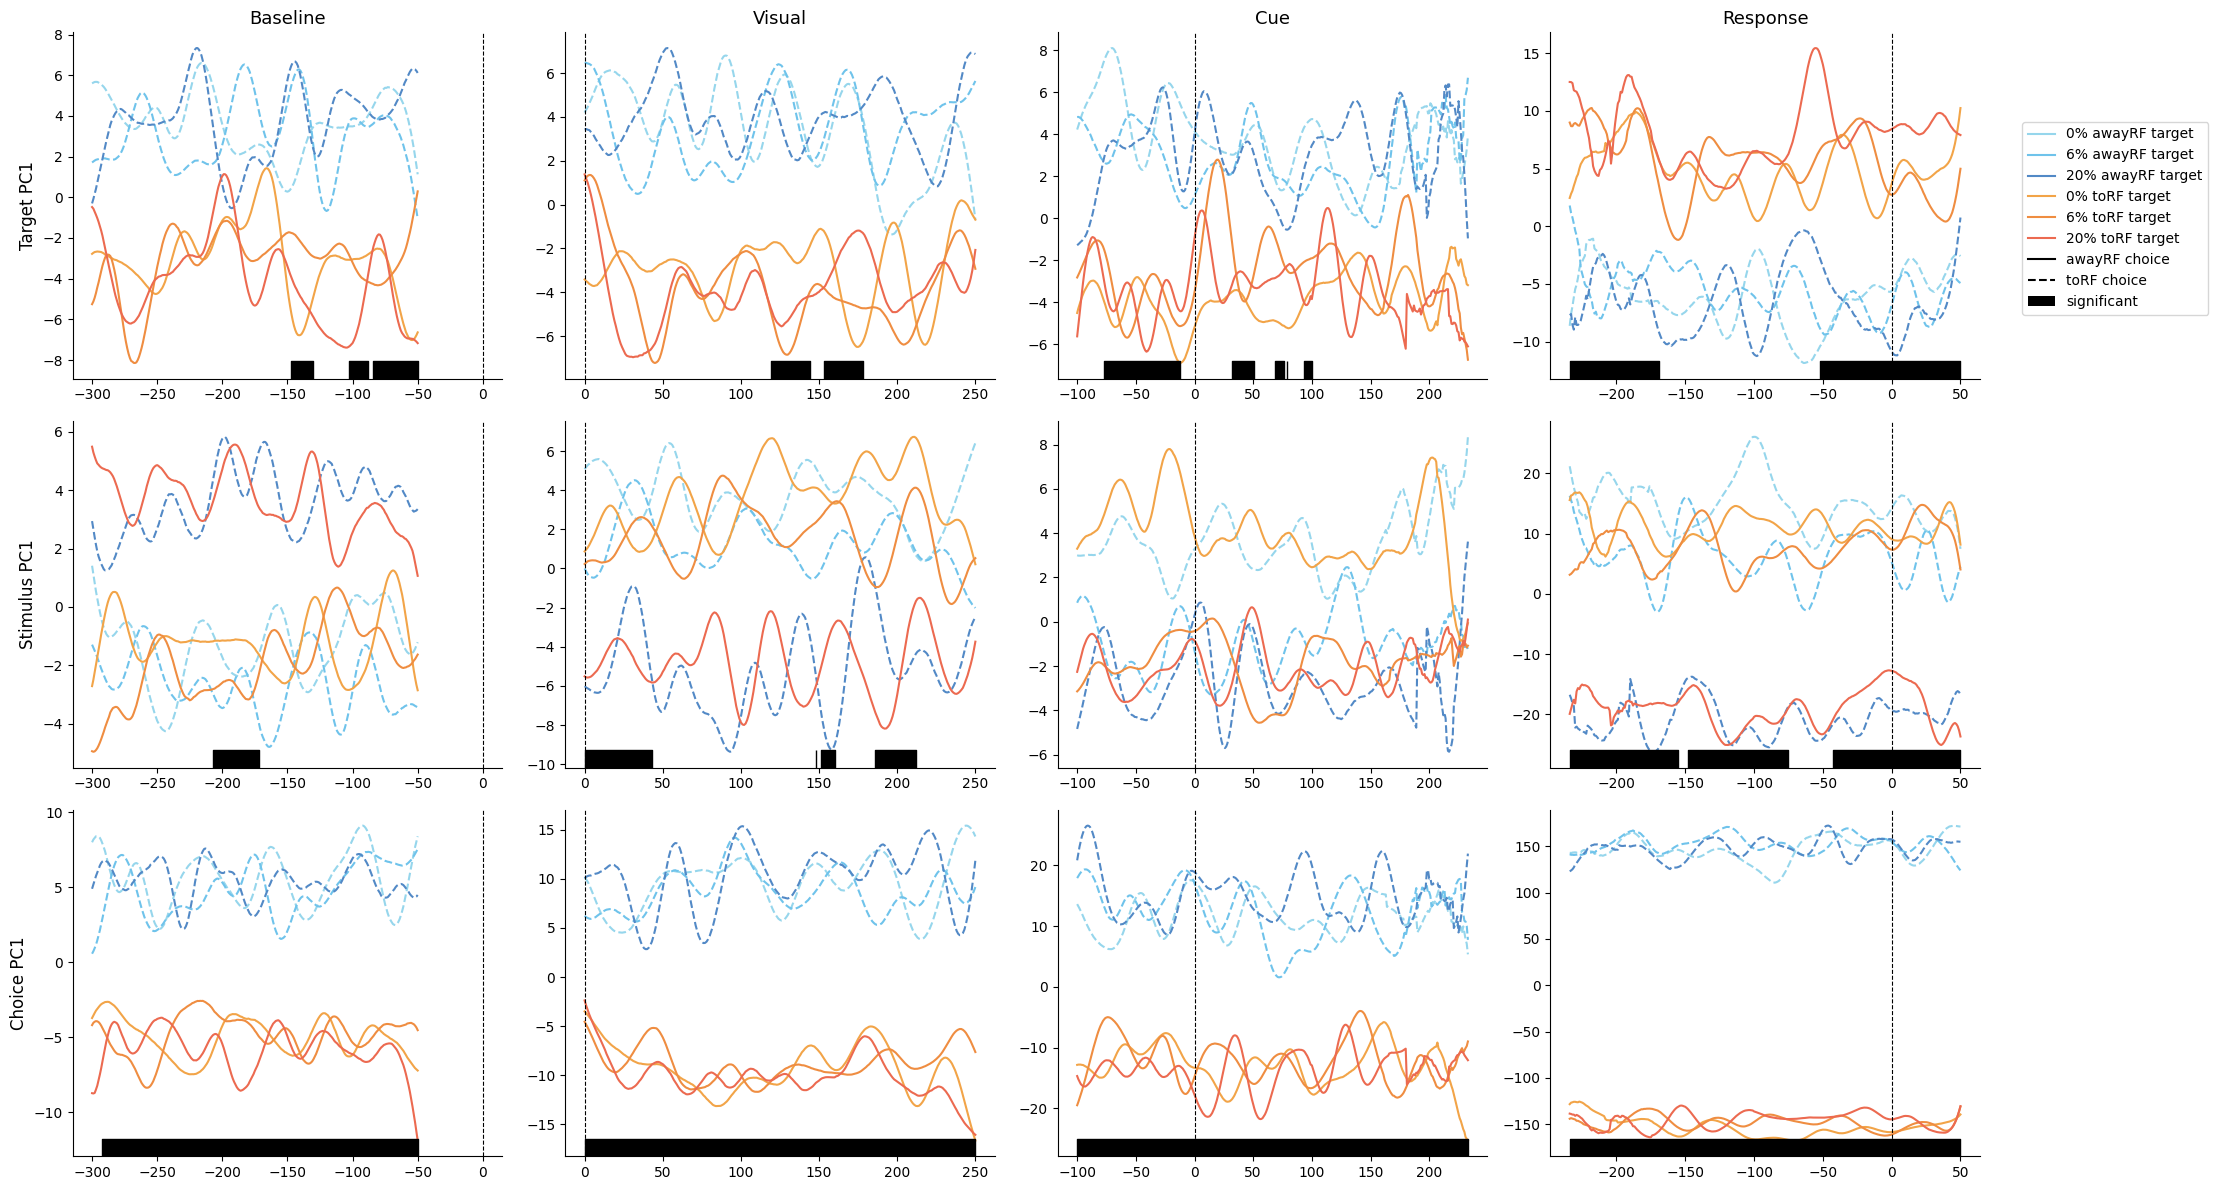

In [13]:
PC = 0
margs_to_plot = ['g', 's', 'c']

figs = {}
for trial_type in ["correct", "error"]:
    print(f"\n{trial_type.upper()} TRIALS:")
    fig = plot_self_projection(
        projection[trial_type], time_axes[trial_type], alignments, margs_to_plot,
        significance_masks=significance_masks[trial_type], PC=PC,
        n_coh=len(condition_dict_blocks["coherences"]),
        coh_labels=COH_LABELS,
    )
    figs[trial_type] = fig
    plt.show()

In [14]:
# ── Save outputs ──────────────────────────────────────────────────────────────
_out = Path("../dissemination/dpca/dpca_toRF_session_all_neuron_target_added")
_out.mkdir(parents=True, exist_ok=True)


# with open(processed_dir/ 'dpca' / "toRF_session_eq_block_target_added_all_neuron_significance_masks.pkl", "wb") as _f:
#     pickle.dump(significance_masks, _f)

# fig = dpca_plot_utils.plot_variance_explained(dpca_results, alignments, ['g', 's', 'c', 't'], n_components=3)
# fig.savefig(_out / "variance_explained_target_added.png", dpi=150, bbox_inches="tight")
# plt.close(fig)

for trial_type in ["correct", "error"]:
    figs[trial_type].savefig(_out / f"self_projection_target_added_{trial_type}_projection.png", dpi=150, bbox_inches="tight")
    plt.close(figs[trial_type])

print(f"Saved → {_out}")


Saved → ../dissemination/dpca/dpca_toRF_session_all_neuron_target_added
